In [1]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri("../mlruns")
experiment_id = "914879025403898454"
client = mlflow.tracking.MlflowClient()


In [2]:
# runs = ["288611b410b24effb259a5255f40ded4","1bdd141dedae49158453f21484f68893","45f1860155cb47d7a9f443b5a19d3a2b","311531096c934996a31462b03f083d05","408c64837abe437fbb07e4ed29646b0b"]
runs=["894c779caea64dee8d15fa02368865c9","68764b0737eb4b37b68ab8964623189c","f96ccc0ec05e436e89ef17f18f4ca21f","c86a246338604a35ad7e31a7cbe60fd2","bc257b456580460f9ef304f36f8f8a40","98d5e35107a7460eab5833bbe2d951be","8088d867ac704a23a4be713f6613474a","64d116de86b04fffa9e9d60211351448","d3b4749d4d97441888fa3dc34a4e0dca","01e8eabab17c49d2b90f6c3927e05d07","ef95f63f65d148aa95e704d560242610","826f0498ba4e4ee298cfea06661c9299","e63538b771c44c3a83a78a3f1bd121f3","fd5a978cec5442ccad007b2055fefc42","1c0f70889a184a4782850e6dd8fc4a1c","d1677fb6ceda482b92f096580b77da39","18b86c541fa74c638098e62235bccdf9","a25985b5eb42457988136637e7a9ab70","13b607e30cfc4c36a16670a8eb6350c8","408c64837abe437fbb07e4ed29646b0b","311531096c934996a31462b03f083d05","45f1860155cb47d7a9f443b5a19d3a2b","1bdd141dedae49158453f21484f68893","288611b410b24effb259a5255f40ded4"]
ids_str = ", ".join(f"'{run}'" for run in runs)  # Оборачиваем каждое значение в одинарные кавычки
filter_string = f"attributes.run_id IN ({ids_str})"  # Формируем финальный запрос
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

In [3]:
runs["params.epsilon"]

0     0.03137254901960784
1     0.03137254901960784
2     0.03137254901960784
3     0.03137254901960784
4     0.03137254901960784
5     0.03137254901960784
6     0.03137254901960784
7     0.03137254901960784
8     0.03137254901960784
9     0.03137254901960784
10    0.03137254901960784
11    0.03137254901960784
12    0.03137254901960784
13    0.03137254901960784
14    0.03137254901960784
15    0.03137254901960784
16    0.03137254901960784
17    0.03137254901960784
18    0.03137254901960784
19    0.03137254901960784
20    0.03137254901960784
21    0.03137254901960784
22    0.03137254901960784
23    0.03137254901960784
Name: params.epsilon, dtype: object

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

FLOAT_RE = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def parse_loss_weights_field(x):
    if pd.isna(x):
        return (1.0, 1.0)
    if isinstance(x, (list, tuple)):
        nums = []
        for v in x:
            try:
                nums.append(float(v))
            except Exception:
                nums += [float(m) for m in FLOAT_RE.findall(str(v))]
        if len(nums) >= 2:
            return (float(nums[0]), float(nums[1]))
        if len(nums) == 1:
            return (float(nums[0]), 1.0)
        return (1.0, 1.0)

    s = str(x)
    nums = FLOAT_RE.findall(s)
    if len(nums) >= 2:
        return (float(nums[0]), float(nums[1]))
    if len(nums) == 1:
        return (float(nums[0]), 1.0)
    return (1.0, 1.0)


loss_weights = (
  "1.0,1.0",
  "1.0,0.5",
  "1.0,0.25",
  "1.0,0.1",
  "1.0,0.05",
  "0.5,1.0",
  "0.25,1.0",
  "0.1,1.0",
  "0.05,1.0",
  "0.75,0.25",
  "0.25,0.75",
  "0.5,0.5",
)

def plot_depth_and_flow_by_attack_mde_loss_weights(
        runs_data,
        depth_prefix='mean_mde_rmse_target_attack_step_',
        flow_prefix='mean_aee_target_attack_step_'):
    df = runs_data.copy()

    if "params.epsilon" in df.columns:
        try:
            df["params.epsilon"] = df["params.epsilon"].astype(float)
        except Exception:
            pass

    if "params.attack_mde" in df.columns:
        df["attack_mde"] = df["params.attack_mde"].astype(bool)
    else:
        df["attack_mde"] = True

    if "params.loss_weights" not in df.columns:
        raise KeyError("DataFrame должен содержать колонку 'params.loss_weights'")

    allowed_combos = [tuple(map(float, s.split(","))) for s in loss_weights]

    # inside your function
    parsed = df["params.loss_weights"].apply(parse_loss_weights_field)
    df["loss_flow_w"] = parsed.apply(lambda t: t[0])
    df["loss_mde_w"]  = parsed.apply(lambda t: t[1])

    # restrict combos only to allowed set
    combos = (
        df[["loss_flow_w", "loss_mde_w"]]
        .drop_duplicates()
        .apply(tuple, axis=1)
        .tolist()
    )
    combos = [c for c in combos if c in allowed_combos]   # <-- filter here
    combos = sorted(combos, key=lambda t: (t[0], t[1]))

    cmap = plt.cm.plasma(np.linspace(0,1,len(combos))) if combos else {}
    combo_to_color = {combo: cmap[i] for i, combo in enumerate(combos)}

    def gather_mean(subdf, prefix):
        data = {}
        for col in subdf.columns:
            if not col.startswith("metrics."+prefix):
                continue
            m = re.search(r'(\d+)$', col)
            if not m:
                continue
            step = int(m.group(1))
            vals = pd.to_numeric(subdf[col], errors='coerce').dropna()
            if not vals.empty:
                data[step] = vals.mean()
        return data

    df_attack = df[df["attack_mde"]]

    fig, (ax_d, ax_f) = plt.subplots(1,2,figsize=(16,6))
    fig.suptitle("Depth RMSE and Flow AEE for different loss_weights (attack_mde)", fontsize=18)

    # DEPTH subplot (log scale)
    for combo in combos:
        flow_w, mde_w = combo
        subset = df_attack[(np.isclose(df_attack["loss_flow_w"], flow_w)) &
                           (np.isclose(df_attack["loss_mde_w"], mde_w))]
        if subset.empty:
            continue
        dvals = gather_mean(subset, depth_prefix)
        if not dvals:
            continue
        steps, metrics = zip(*sorted(dvals.items()))
        # make safe for log scale: replace non-positive values with a small positive fallback
        metrics = np.array(metrics, dtype=float)
        if np.any(metrics <= 0):
            pos = metrics[metrics > 0]
            if pos.size > 0:
                fallback = float(np.min(pos)) * 0.1
            else:
                fallback = 1e-8
            metrics = np.where(metrics <= 0, fallback, metrics)

        label = f"flow={flow_w:.3f}, mde={mde_w:.3f}"
        ax_d.plot(steps,
                  metrics,
                  marker="o",
                  label=label,
                  color=combo_to_color[combo],
                  linestyle="-")

    ax_d.set_title("Depth RMSE vs Attack Iteration (log y-scale)")
    ax_d.set_xlabel("Attack iteration (step)")
    ax_d.set_ylabel("Depth RMSE")
    # ax_d.set_yscale('log')               # <-- set log scale here
    ax_d.grid(True, which='both', ls='--', lw=0.5)  # grid for both major & minor ticks
    h, l = ax_d.get_legend_handles_labels()
    if l:
        ax_d.legend(title="loss weights", loc='best')

    # FLOW subplot (linear)
    for combo in combos:
        flow_w, mde_w = combo
        subset = df_attack[(np.isclose(df_attack["loss_flow_w"], flow_w)) &
                           (np.isclose(df_attack["loss_mde_w"], mde_w))]
        if subset.empty:
            continue
        fvals = gather_mean(subset, flow_prefix)
        if not fvals:
            continue
        steps, metrics = zip(*sorted(fvals.items()))
        label = f"flow={flow_w:.3f}, mde={mde_w:.3f}"
        ax_f.plot(steps,
                  metrics,
                  marker="o",
                  label=label,
                  color=combo_to_color[combo],
                  linestyle="-")

    ax_f.set_title("Mean AEE vs Attack Iteration")
    ax_f.set_xlabel("Attack iteration (step)")
    ax_f.set_ylabel("Mean AEE")
    ax_f.grid(True)
    h, l = ax_f.get_legend_handles_labels()
    if l:
        ax_f.legend(title="loss weights", loc='best')

    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()


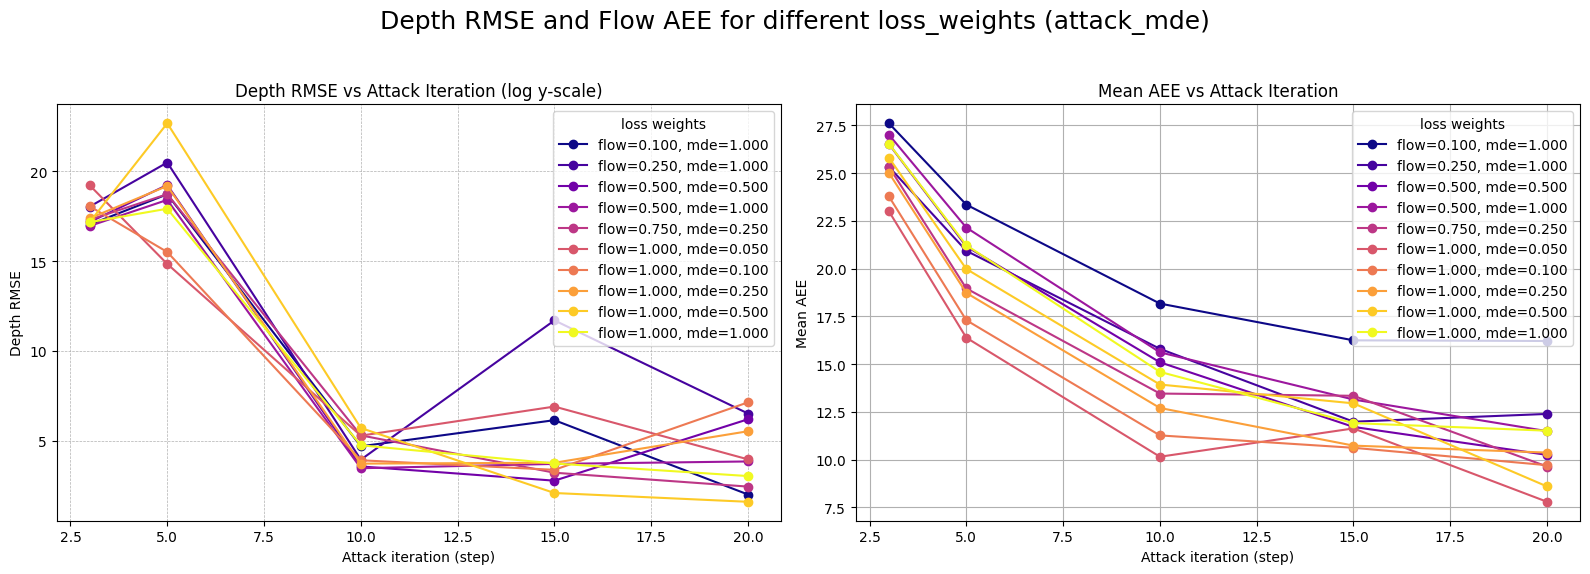

In [9]:
plot_depth_and_flow_by_attack_mde_loss_weights(runs)

In [2]:
runs = ["cfafd5cae35e4641b9c2d4e4ce3e6620","76b2ad5ef88a46908c167ee139cf2198","0915266adcdf40d3bf167f1e607925ff"]
ids_str = ", ".join(f"'{run}'" for run in runs)  # Оборачиваем каждое значение в одинарные кавычки
filter_string = f"attributes.run_id IN ({ids_str})"  # Формируем финальный запрос
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re


def _get_final_metric_value(subdf, base_name_no_step, step_suffix_pattern="_step_"):
    """
    Возвращает среднее значение метрики:
    — если есть столбец без суффикса (например, 'metrics.mean_mde_rmse_target_attack'),
      берёт его;
    — иначе ищет все *_step_<N> и берёт последний шаг (максимальный N).
    """
    col_plain = "metrics." + base_name_no_step
    if col_plain in subdf.columns:
        vals = pd.to_numeric(subdf[col_plain], errors='coerce').dropna()
        return vals.mean() if not vals.empty else np.nan

    matching = [c for c in subdf.columns if c.startswith(
        "metrics." + base_name_no_step)]
    if not matching:
        return np.nan

    step_cols = []
    for c in matching:
        m = re.search(r"(\d+)$", c)
        step_cols.append((int(m.group(1)) if m else 0, c))
    step_cols.sort()
    chosen_col = step_cols[-1][1]

    vals = pd.to_numeric(subdf[chosen_col], errors="coerce").dropna()
    return vals.mean() if not vals.empty else np.nan


def plot_three_mode_depth_flow_separate(
    runs_data: pd.DataFrame,
    loss_weights_col="params.loss_weights",
    depth_metric_name="mean_mde_rmse_target_attack",
    flow_metric_name="mean_aee_target_attack",
    title_prefix="Patch attack metrics by mode",
):
    """
    Строит два отдельных графика:
      1️⃣ Depth RMSE по трём сценариям: flow_only, mde_only, both
      2️⃣ Flow AEE по тем же сценариям
    """
    df = runs_data.copy()

    if loss_weights_col not in df.columns:
        raise KeyError(
            f"DataFrame должен содержать колонку '{loss_weights_col}'")

    parsed = df[loss_weights_col].apply(parse_loss_weights_field)
    df["loss_flow_w"] = parsed.apply(lambda t: t[0])
    df["loss_mde_w"] = parsed.apply(lambda t: t[1])

    def classify_row(r):
        fw, mw = float(r["loss_flow_w"]), float(r["loss_mde_w"])
        if np.isclose(mw, 0.0) and not np.isclose(fw, 0.0):
            return "flow_only"
        elif np.isclose(fw, 0.0) and not np.isclose(mw, 0.0):
            return "mde_only"
        elif (not np.isclose(fw, 0.0)) and (not np.isclose(mw, 0.0)):
            return "both"
        else:
            return "other"

    df["mode"] = df.apply(classify_row, axis=1)

    modes = ["flow_only", "mde_only", "both"]
    depth_vals, flow_vals, counts = [], [], []

    for mode in modes:
        sub = df[df["mode"] == mode]
        counts.append(len(sub))
        if sub.empty:
            depth_vals.append(np.nan)
            flow_vals.append(np.nan)
            continue
        depth_val = _get_final_metric_value(sub, depth_metric_name)
        flow_val = _get_final_metric_value(sub, flow_metric_name)
        depth_vals.append(depth_val)
        flow_vals.append(flow_val)

    # === Plot 1: Depth RMSE ===
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax_d, ax_f = axes

    x = np.arange(len(modes))
    width = 0.6

    ax_d.bar(x, depth_vals, color="tab:blue", width=width)
    ax_d.set_xticks(x)
    ax_d.set_xticklabels([f"{m}\n(n={c})" for m, c in zip(modes, counts)])
    ax_d.set_title(f"{title_prefix}: Depth RMSE")
    ax_d.set_ylabel("Depth RMSE ↓ (меньше — лучше)")
    ax_d.grid(axis="y", ls="--", lw=0.5, alpha=0.7)

    # === Plot 2: Flow AEE ===
    ax_f.bar(x, flow_vals, color="tab:orange", width=width)
    ax_f.set_xticks(x)
    ax_f.set_xticklabels([f"{m}\n(n={c})" for m, c in zip(modes, counts)])
    ax_f.set_title(f"{title_prefix}: Flow AEE")
    ax_f.set_ylabel("Flow AEE ↓ (меньше — лучше)")
    ax_f.grid(axis="y", ls="--", lw=0.5, alpha=0.7)

    plt.tight_layout()
    plt.show()

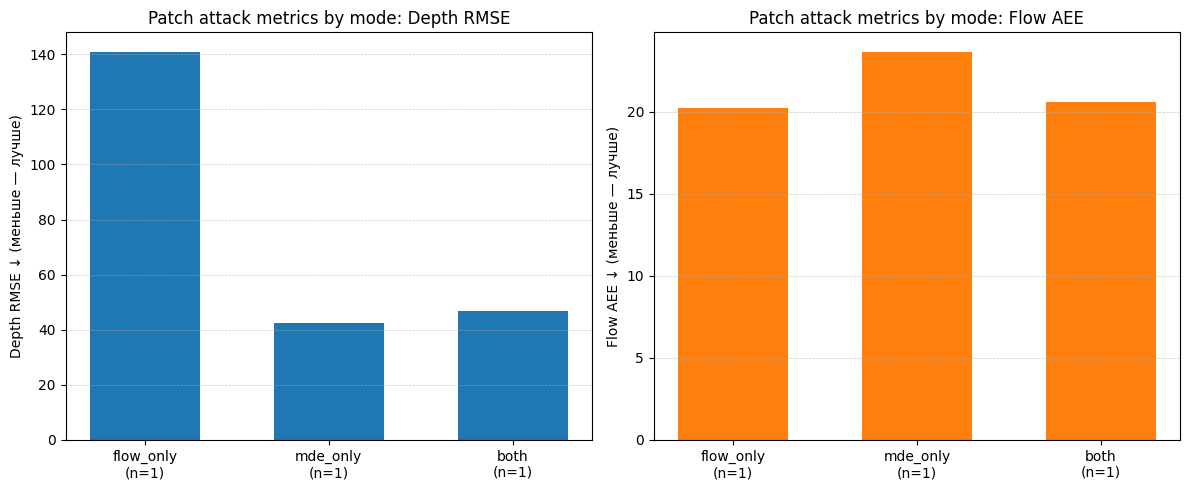

In [10]:
plot_three_mode_depth_flow_separate(runs)

In [2]:
# runs = ["288611b410b24effb259a5255f40ded4","1bdd141dedae49158453f21484f68893","45f1860155cb47d7a9f443b5a19d3a2b","311531096c934996a31462b03f083d05","408c64837abe437fbb07e4ed29646b0b"]
runs = ["0488e2b6630447d0ac91a467de7e754d", "32edb3dbef4442c2aae16c748e54ea15", "95b51b396f7744c4b4cd129d857eafe3", "a58ab68b1bc74b0dbd287bf32d0cba46",
        "d11ca86a13d04718af67304a265e9df3", "e2982aa35c2d4b6e9ba94d5164bd6d16", "1ef32b24c83c46d991610349ca478a1f", "c85364fde7074ea48fddd54ee4d24012"]
# Оборачиваем каждое значение в одинарные кавычки
ids_str = ", ".join(f"'{run}'" for run in runs)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)

In [21]:
def plot_depth_flow_seg_by_attack_seg_loss_weights(
        runs_data,
        depth_prefix='mean_mde_rmse_target_attack_step_',
        flow_prefix='mean_aee_target_attack_step_',
        seg_metric='metrics.mean_ase_target_attack'):
    """
    Строит три графика:
      1) Depth RMSE vs attack iteration
      2) Flow AEE vs attack iteration
      3) Mean ASE (сегментация) vs segmentation loss weight
    """
    df = runs_data.copy()

    if "params.epsilon" in df.columns:
        try:
            df["params.epsilon"] = df["params.epsilon"].astype(float)
        except Exception:
            pass

    if "params.attack_mde" in df.columns:
        df["attack_mde"] = df["params.attack_mde"].astype(bool)
    else:
        df["attack_mde"] = True

    if "params.loss_weights" not in df.columns:
        raise KeyError(
            "DataFrame должен содержать колонку 'params.loss_weights'")

    # --- Парсим веса ---
    parsed = df["params.loss_weights"].apply(parse_loss_weights_field)
    df["loss_flow_w"] = parsed.apply(lambda t: t[0])
    df["loss_mde_w"] = parsed.apply(lambda t: t[1])

    # Добавляем вес сегментации (3-е число, если есть)
    df["loss_seg_w"] = df["params.loss_weights"].apply(
        lambda x: float(FLOAT_RE.findall(str(x))[2]) if len(
            FLOAT_RE.findall(str(x))) >= 3 else 1.0
    )

    seg_weights = sorted(df["loss_seg_w"].dropna().unique())
    cmap = plt.cm.plasma(np.linspace(
        0, 1, len(seg_weights))) if seg_weights else {}
    seg_to_color = {w: cmap[i] for i, w in enumerate(seg_weights)}

    def gather_mean(subdf, prefix):
        """Собирает средние значения по шагам атаки"""
        data = {}
        for col in subdf.columns:
            if not col.startswith("metrics." + prefix):
                continue
            m = re.search(r"(\d+)$", col)
            if not m:
                continue
            step = int(m.group(1))
            vals = pd.to_numeric(subdf[col], errors="coerce").dropna()
            if not vals.empty:
                data[step] = vals.mean()
        return data

    df_attack = df[df["attack_mde"]]

    # --- Визуализация ---
    fig, (ax_d, ax_f, ax_s) = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(
        "Depth RMSE, Flow AEE и Segmentation ASE при разных весах сегментации", fontsize=18)

    # DEPTH subplot
    for seg_w in seg_weights:
        subset = df_attack[np.isclose(df_attack["loss_seg_w"], seg_w)]
        if subset.empty:
            continue
        dvals = gather_mean(subset, depth_prefix)
        if not dvals:
            continue
        steps, metrics = zip(*sorted(dvals.items()))
        metrics = np.array(metrics, dtype=float)
        metrics = np.where(metrics <= 0, np.min(
            metrics[metrics > 0]) * 0.1 if np.any(metrics > 0) else 1e-8, metrics)
        ax_d.plot(steps, metrics, marker="o",
                  label=f"seg_w={seg_w:.3f}", color=seg_to_color[seg_w])
    ax_d.set_title("Depth RMSE vs Attack Iteration")
    ax_d.set_xlabel("Attack iteration (step)")
    ax_d.set_ylabel("Depth RMSE")
    ax_d.grid(True)
    ax_d.legend(title="Segmentation weight")

    # FLOW subplot
    for seg_w in seg_weights:
        subset = df_attack[np.isclose(df_attack["loss_seg_w"], seg_w)]
        if subset.empty:
            continue
        fvals = gather_mean(subset, flow_prefix)
        if not fvals:
            continue
        steps, metrics = zip(*sorted(fvals.items()))
        ax_f.plot(steps, metrics, marker="o",
                  label=f"seg_w={seg_w:.3f}", color=seg_to_color[seg_w])
    ax_f.set_title("Flow AEE vs Attack Iteration")
    ax_f.set_xlabel("Attack iteration (step)")
    ax_f.set_ylabel("Mean AEE")
    ax_f.grid(True)
    ax_f.legend(title="Segmentation weight")

    # SEGMENTATION subplot (бар-чарт по ASE)
    seg_means = []
    for seg_w in seg_weights:
        subset = df_attack[np.isclose(df_attack["loss_seg_w"], seg_w)]
        if subset.empty or seg_metric not in subset.columns:
            seg_means.append(np.nan)
            print('!!')
        else:
            vals = pd.to_numeric(subset[seg_metric], errors="coerce").dropna()
            seg_means.append(vals.mean() if not vals.empty else np.nan)

    ax_s.bar([str(w) for w in seg_weights], seg_means,
             color=[seg_to_color[w] for w in seg_weights])
    ax_s.set_title("Segmentation ASE vs Segmentation Weight")
    ax_s.set_xlabel("Segmentation loss weight")
    ax_s.set_ylabel("Mean ASE")
    ax_s.grid(axis="y")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

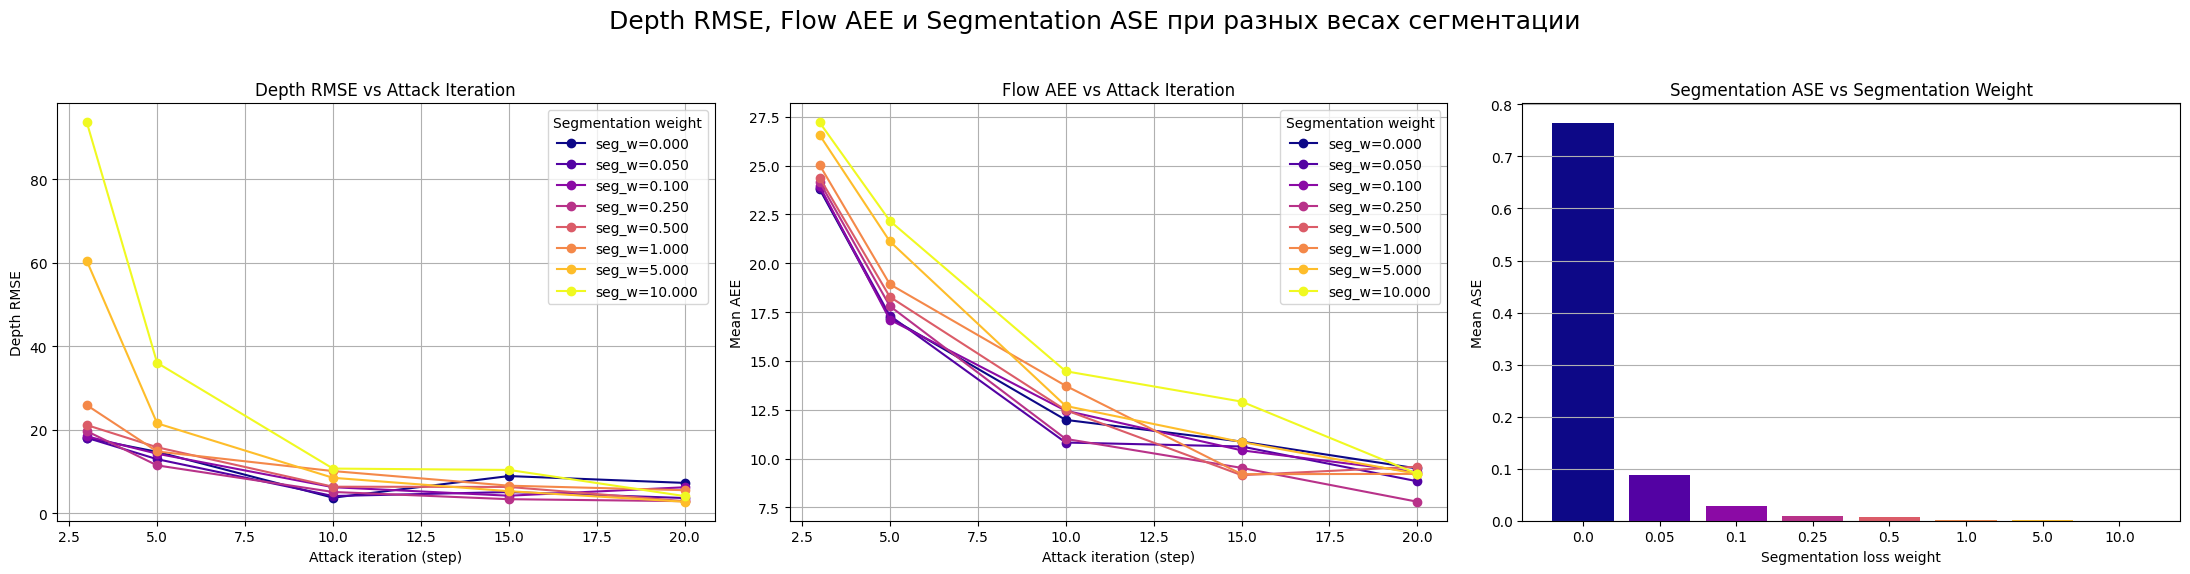

In [22]:
plot_depth_flow_seg_by_attack_seg_loss_weights(runs)

In [16]:
runs['metrics.mean_ase_target_attack']

0    0.763881
1    0.087645
2    0.028073
3    0.008297
4    0.006438
5    0.001524
6    0.000454
7    0.000152
Name: metrics.mean_ase_target_attack, dtype: float64

In [1]:
import mmseg
import mmengine
import mmcv

print(mmseg.__version__)
print(mmengine.__version__)
print(mmcv.__version__)

1.2.2
0.10.7
2.2.0


In [2]:
from mmseg.models import build_segmentor
from mmseg.models.decode_heads import Mask2FormerHead
print(Mask2FormerHead.__init__.__doc__)

None


In [3]:
!pip install "mmdet>=3.0.0rc4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mmdet]32m2/3 [mmdet]y]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Cityscapes 19 классов + их имена
classes = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

num_classes = len(classes)

# используем matplotlib colormap tab20
cmap = plt.get_cmap('tab20')
color_map = (np.array([cmap(i / num_classes)[:3]
             for i in range(num_classes)]) * 255).astype(np.uint8)

# создаём справочную картинку
swatch_height = 50
swatch_width = 200
legend_img = np.zeros((swatch_height * num_classes,
                      swatch_width, 3), dtype=np.uint8)

for i, color in enumerate(color_map):
    y0 = i * swatch_height
    y1 = y0 + swatch_height
    legend_img[y0:y1, :, :] = color
    cv2.putText(
        legend_img, classes[i], (10, y0 + 35),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255) if np.mean(
            color) < 128 else (0, 0, 0), 2
    )

# сохраняем в файл
cv2.imwrite("cityscapes_color_legend.png",
            cv2.cvtColor(legend_img, cv2.COLOR_RGB2BGR))
print("Saved cityscapes_color_legend.png")

Saved cityscapes_color_legend.png
